<a href="https://colab.research.google.com/github/ysuter/FHNW-BAI-ComputerVision/blob/main/Fourier_Reihen_Interaktiv.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🌊 Interaktive Fourier-Reihen Demonstration
## Zerlegung periodischer Signale in Summen von Sinuswellen

---

**Die zentrale Idee:**

> Jedes periodische Signal kann als Summe von Sinus- und Kosinuswellen dargestellt werden!

Dieses Notebook ermöglicht Ihnen:
- Verschiedene periodische Wellenformen wählen (Rechteck, Dreieck, Sägezahn)
- Anzahl der Harmonischen anpassen
- Sehen wie sich die Approximation mit mehr Harmonischen verbessert
- Einzelne harmonische Komponenten visualisieren

---

## 📦 Setup

In [1]:
# Bibliotheken installieren und importieren
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import ipywidgets as widgets
from IPython.display import display, clear_output, HTML

# Plotting konfigurieren
plt.rcParams['figure.figsize'] = (16, 10)
plt.rcParams['font.size'] = 10
%matplotlib inline

print('✅ Alle Bibliotheken geladen!')
print('🌊 Bereit zur Erkundung der Fourier-Reihen')

✅ Alle Bibliotheken geladen!
🌊 Bereit zur Erkundung der Fourier-Reihen


---

## 📚 Kurztheorie: Was ist eine Fourier-Reihe?

### Die Fourier-Reihen-Formel:

Jede periodische Funktion f(t) mit Periode T kann geschrieben werden als:

$$f(t) = a_0 + \sum_{n=1}^{\infty} \left[ a_n \cos(n\omega_0 t) + b_n \sin(n\omega_0 t) \right]$$

Wobei:
- $\omega_0 = 2\pi/T$ ist die Grundfrequenz
- $a_0$ = DC-Komponente (Mittelwert)
- $a_n, b_n$ = Fourier-Koeffizienten für die n-te Harmonische
- Jeder Term ist eine **Harmonische** (ganzzahliges Vielfaches der Grundfrequenz)

### Wichtige Erkenntnisse:

1. **Mehr Harmonische = bessere Approximation**
2. **Gerade/ungerade Symmetrie** beeinflusst, welche Koeffizienten nicht null sind
3. **Scharfe Kanten** erfordern viele hochfrequente Harmonische
4. **Glatte Kurven** benötigen weniger Harmonische

---

## 🔧 Implementierung: Wellenform-Generatoren und Fourier-Koeffizienten

In [7]:
class FourierReihenDemo:
    """Interaktive Fourier-Reihen Demonstration"""

    def __init__(self, num_periods=3, num_points=1000):
        self.num_periods = num_periods
        self.num_points = num_points
        self.t = np.linspace(0, num_periods * 2 * np.pi, num_points)

    # ===== Wellenform-Generatoren =====

    def rechteckwelle(self, t, amplitude=1.0, duty_cycle=0.5):
        """Rechteckwelle erzeugen"""
        return amplitude * np.where(np.sin(t) >= 0, 1, -1)

    def dreieckwelle(self, t, amplitude=1.0):
        """Dreieckwelle erzeugen"""
        return amplitude * (2 * np.abs(2 * ((t / (2*np.pi)) % 1) - 1) - 1)

    def saegezahnwelle(self, t, amplitude=1.0):
        """Sägezahnwelle erzeugen"""
        return amplitude * (2 * ((t / (2*np.pi)) % 1) - 1)

    def impulszug(self, t, amplitude=1.0, duty_cycle=0.2):
        """Impulszug erzeugen (schmale Impulse)"""
        phase = (t / (2*np.pi)) % 1
        return amplitude * np.where(phase < duty_cycle, 1, -1)

    def halbwellen_gleichgerichtet(self, t, amplitude=1.0):
        """Halbwellen-gleichgerichteter Sinus"""
        sine = amplitude * np.sin(t)
        return np.where(sine > 0, sine, 0)

    def vollwellen_gleichgerichtet(self, t, amplitude=1.0):
        """Vollwellen-gleichgerichteter Sinus"""
        return amplitude * np.abs(np.sin(t))

    # ===== Fourier-Koeffizienten Berechnung =====

    def berechne_fourier_koeffizienten(self, signal, n_harmonics):
        """
        Fourier-Reihen-Koeffizienten mittels numerischer Integration berechnen

        Rückgabe:
        - a0: DC-Komponente
        - an: Kosinus-Koeffizienten (Array)
        - bn: Sinus-Koeffizienten (Array)
        """
        T = 2 * np.pi  # Periode
        N = len(signal)
        t = np.linspace(0, self.num_periods * T, N)

        # Eine Periode für Koeffizientenberechnung extrahieren
        one_period_samples = N // self.num_periods
        signal_one_period = signal[:one_period_samples]
        t_one_period = t[:one_period_samples]

        # DC-Komponente (Mittelwert)
        a0 = np.mean(signal_one_period)

        # Koeffizienten für jede Harmonische berechnen
        an = np.zeros(n_harmonics)
        bn = np.zeros(n_harmonics)

        for n in range(1, n_harmonics + 1):
            # Kosinus-Koeffizient
            an[n-1] = (2/T) * np.trapz(
                signal_one_period * np.cos(n * t_one_period),
                t_one_period
            )

            # Sinus-Koeffizient
            bn[n-1] = (2/T) * np.trapz(
                signal_one_period * np.sin(n * t_one_period),
                t_one_period
            )

        return a0, an, bn

    def rekonstruiere_signal(self, a0, an, bn, n_harmonics_to_use):
        """
        Signal aus Fourier-Koeffizienten rekonstruieren

        Parameter:
        - a0: DC-Komponente
        - an, bn: Fourier-Koeffizienten
        - n_harmonics_to_use: Anzahl der zu verwendenden Harmonischen

        Rückgabe:
        - reconstructed: Approximiertes Signal
        - harmonics: Liste einzelner harmonischer Komponenten
        """
        reconstructed = np.ones_like(self.t) * a0
        harmonics = []

        for n in range(1, min(n_harmonics_to_use + 1, len(an) + 1)):
            # Jede harmonische Komponente
            harmonic = an[n-1] * np.cos(n * self.t) + bn[n-1] * np.sin(n * self.t)
            harmonics.append(harmonic)
            reconstructed += harmonic

        return reconstructed, harmonics

    # ===== Visualisierung =====

    # ========================================
# ERWEITERTE PLOT-FUNKTION MIT SPEKTREN
# ========================================
# Fügen Sie diese Zelle NACH der FourierReihenDemo Klasse ein!

# Diese Funktion ersetzt/erweitert die plot_zerlegung Methode
def plot_zerlegung_mit_spektren(self, wellenform_typ, n_harmonics, zeige_harmonische=True):
    """
    Fourier-Zerlegung MIT Amplituden- und Phasenspektrum

    NEU: Zeigt zwei zusätzliche Plots für Amplitude und Phase!
    """
    # Wellenformen
    wellenform_funcs = {
        'Rechteckwelle': self.rechteckwelle,
        'Dreieckwelle': self.dreieckwelle,
        'Sägezahnwelle': self.saegezahnwelle,
        'Impulszug': self.impulszug,
        'Halbwellen-Gleichgerichtet': self.halbwellen_gleichgerichtet,
        'Vollwellen-Gleichgerichtet': self.vollwellen_gleichgerichtet
    }

    # Signal erzeugen
    original = wellenform_funcs[wellenform_typ](self.t)

    # Fourier-Koeffizienten
    max_harmonics = 50
    a0, an, bn = self.berechne_fourier_koeffizienten(original, max_harmonics)

    # *** AMPLITUDEN UND PHASEN BERECHNEN ***
    amplitudes = np.sqrt(an**2 + bn**2)
    phases = np.arctan2(-bn, an)  # Phase in Radiant

    # Rekonstruktion
    reconstructed, harmonics = self.rekonstruiere_signal(a0, an, bn, n_harmonics)
    error = np.mean((original - reconstructed)**2)

    # ===== LAYOUT: 3 Zeilen =====
    fig = plt.figure(figsize=(18, 14))
    gs = GridSpec(3, 2, figure=fig, hspace=0.4, wspace=0.3,
                 height_ratios=[1.5, 1.2, 1])

    # Zeile 1: Hauptplot (volle Breite)
    ax_main = fig.add_subplot(gs[0, :])

    # Zeile 2: AMPLITUDEN- UND PHASENSPEKTRUM
    ax_amplitude = fig.add_subplot(gs[1, 0])
    ax_phase = fig.add_subplot(gs[1, 1])

    # Zeile 3: Erste 2 Harmonische
    if zeige_harmonische and n_harmonics > 0:
        ax_h1 = fig.add_subplot(gs[2, 0])
        ax_h2 = fig.add_subplot(gs[2, 1])

    # ===== PLOT 1: SIGNAL =====
    ax_main.plot(self.t, original, 'b-', linewidth=2.5, label='Original', alpha=0.7)
    ax_main.plot(self.t, reconstructed, 'r--', linewidth=2.5,
                label=f'Rekonstruktion ({n_harmonics} Harmonische)')
    ax_main.set_xlabel('t (Radiant)', fontsize=13, fontweight='bold')
    ax_main.set_ylabel('Amplitude', fontsize=13, fontweight='bold')
    ax_main.set_title(f'{wellenform_typ} - Fourier-Approximation (Fehler: {error:.6f})',
                    fontsize=15, fontweight='bold')
    ax_main.legend(fontsize=12, loc='upper right')
    ax_main.grid(True, alpha=0.3, linestyle='--')
    ax_main.set_xlim(0, 4*np.pi)

    # ===== PLOT 2: AMPLITUDENSPEKTRUM =====
    n_values = np.arange(1, len(amplitudes) + 1)

    # Alle Harmonischen (grau)
    ax_amplitude.stem(n_values[:30], amplitudes[:30],
                     linefmt='gray', markerfmt='o', basefmt='k-',
                     label='Alle Harmonischen')

    # Verwendete Harmonischen (rot hervorgehoben)
    if n_harmonics > 0:
        markerline, stemlines, baseline = ax_amplitude.stem(
            n_values[:n_harmonics], amplitudes[:n_harmonics],
            linefmt='r-', markerfmt='ro', basefmt='k-',
            label=f'Verwendet (N={n_harmonics})'
        )
        markerline.set_markersize(10)
        stemlines.set_linewidth(2.5)

    ax_amplitude.set_xlabel('Harmonische n', fontsize=12, fontweight='bold')
    ax_amplitude.set_ylabel('Amplitude $A_n = \\sqrt{a_n^2 + b_n^2}$', fontsize=11, fontweight='bold')
    ax_amplitude.set_title('📊 AMPLITUDENSPEKTRUM', fontsize=14, fontweight='bold', color='darkblue')
    ax_amplitude.grid(True, alpha=0.3, linestyle='--')
    ax_amplitude.legend(fontsize=10, loc='upper right')
    ax_amplitude.set_xlim(0, 31)

    # Top 3 Werte beschriften
    top_3 = np.argsort(amplitudes)[-3:][::-1]
    for idx in top_3:
        if idx < 30:
            ax_amplitude.text(idx + 1, amplitudes[idx], f'{amplitudes[idx]:.2f}',
                            ha='center', va='bottom', fontsize=9, fontweight='bold',
                            bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.8))

    # ===== PLOT 3: PHASENSPEKTRUM =====
    # Nur signifikante Phasen zeigen
    significant = amplitudes > 0.01 * amplitudes.max()
    sig_n = n_values[significant][:30]
    sig_phases = phases[significant][:30]

    markerline, stemlines, baseline = ax_phase.stem(
        sig_n, sig_phases,
        linefmt='g-', markerfmt='go', basefmt='k-'
    )
    markerline.set_markersize(8)
    stemlines.set_linewidth(2)

    ax_phase.set_xlabel('Harmonische n', fontsize=12, fontweight='bold')
    ax_phase.set_ylabel('Phase $\\phi_n$ (Radiant)', fontsize=11, fontweight='bold')
    ax_phase.set_title('📐 PHASENSPEKTRUM', fontsize=14, fontweight='bold', color='darkgreen')
    ax_phase.grid(True, alpha=0.3, linestyle='--')
    ax_phase.set_xlim(0, 31)
    ax_phase.set_ylim(-np.pi - 0.3, np.pi + 0.3)

    # Phasen-Referenzlinien
    ax_phase.axhline(0, color='gray', linestyle='--', alpha=0.5, linewidth=1)
    ax_phase.axhline(np.pi, color='gray', linestyle='--', alpha=0.5, linewidth=1)
    ax_phase.axhline(-np.pi, color='gray', linestyle='--', alpha=0.5, linewidth=1)

    # Y-Achse beschriften
    ax_phase.set_yticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi])
    ax_phase.set_yticklabels(['-π', '-π/2', '0', 'π/2', 'π'])

    # ===== HARMONISCHE ANZEIGEN =====
    if zeige_harmonische and n_harmonics > 0:
        if len(harmonics) > 0:
            ax_h1.plot(self.t, harmonics[0], linewidth=2, color='C0')
            ax_h1.set_title(f'1. Harmonische: A₁={amplitudes[0]:.3f}, φ₁={phases[0]:.2f} rad',
                          fontsize=11, fontweight='bold')
            ax_h1.grid(True, alpha=0.3)
            ax_h1.set_xlim(0, 4*np.pi)
            ax_h1.set_ylabel('Amplitude', fontsize=10)

        if len(harmonics) > 1:
            ax_h2.plot(self.t, harmonics[1], linewidth=2, color='C1')
            ax_h2.set_title(f'2. Harmonische: A₂={amplitudes[1]:.3f}, φ₂={phases[1]:.2f} rad',
                          fontsize=11, fontweight='bold')
            ax_h2.grid(True, alpha=0.3)
            ax_h2.set_xlim(0, 4*np.pi)
            ax_h2.set_ylabel('Amplitude', fontsize=10)

    plt.show()

    # ===== AUSGABE =====
    print(f'\\n📊 Fourier-Analyse: {wellenform_typ}')
    print(f'   DC-Komponente: {a0:.4f}')
    print(f'   Harmonische: {n_harmonics}/{max_harmonics}')
    print(f'   MSE: {error:.6f}')

    if n_harmonics > 0:
        print(f'\\n   📈 Top 5 Harmonische:')
        top_5 = np.argsort(amplitudes)[-5:][::-1]
        for i, idx in enumerate(top_5, 1):
            if idx < n_harmonics:
                deg = np.degrees(phases[idx])
                print(f'      {i}. n={idx+1}: A={amplitudes[idx]:.4f}, φ={phases[idx]:.3f} rad ({deg:.1f}°)')

# Funktion zur Demo-Klasse hinzufügen
FourierReihenDemo.plot_zerlegung_mit_spektren = plot_zerlegung_mit_spektren

print('✅ Erweiterte Plot-Funktion mit Spektren geladen!')
print('📊 Verwenden Sie: demo.plot_zerlegung_mit_spektren(...)')

✅ Erweiterte Plot-Funktion mit Spektren geladen!
📊 Verwenden Sie: demo.plot_zerlegung_mit_spektren(...)


---

## 🎮 Interaktive Demo: Erkunden Sie Fourier-Reihen!

**Anleitung:**
1. Wählen Sie einen Wellenform-Typ
2. Passen Sie die Anzahl der Harmonischen an
3. Schalten Sie um, ob einzelne harmonische Komponenten angezeigt werden
4. Beobachten Sie, wie sich die Approximation verbessert!

**Was zu beobachten ist:**
- Mit **0 Harmonischen**: Nur DC-Komponente (Mittelwert)
- Mit **1 Harmonische**: Sinuswellen-Approximation
- Mit **mehr Harmonischen**: Immer bessere Approximation
- **Rechteckwelle** benötigt viele Harmonische (hat scharfe Kanten)
- **Dreieckwelle** konvergiert schneller (glatter)

In [8]:
# Demo-Instanz erstellen
demo = FourierReihenDemo(num_periods=2, num_points=2000)

# Interaktive Widgets erstellen
wellenform_dropdown = widgets.Dropdown(
    options=['Rechteckwelle', 'Dreieckwelle', 'Sägezahnwelle',
             'Impulszug', 'Halbwellen-Gleichgerichtet', 'Vollwellen-Gleichgerichtet'],
    value='Rechteckwelle',
    description='Wellenform:',
    style={'description_width': '120px'},
    layout=widgets.Layout(width='500px')
)

harmonics_slider = widgets.IntSlider(
    value=5,
    min=0,
    max=50,
    step=1,
    description='Harmonische (N):',
    style={'description_width': '120px'},
    layout=widgets.Layout(width='600px')
)

show_harmonics_checkbox = widgets.Checkbox(
    value=True,
    description='Einzelne Harmonische anzeigen',
    style={'description_width': 'initial'}
)

output_widget = widgets.Output()

def update_plot(change):
    with output_widget:
        clear_output(wait=True)
        demo.plot_zerlegung_mit_spektren(
            wellenform_dropdown.value,
            harmonics_slider.value,
            show_harmonics_checkbox.value
        )

# Observer anhängen
wellenform_dropdown.observe(update_plot, names='value')
harmonics_slider.observe(update_plot, names='value')
show_harmonics_checkbox.observe(update_plot, names='value')

# Steuerelemente anzeigen
print('🎮 Interaktiver Fourier-Reihen Explorer')
print('='*60)
display(wellenform_dropdown)
display(harmonics_slider)
display(show_harmonics_checkbox)
display(output_widget)

# Initiales Plot
update_plot(None)

🎮 Interaktiver Fourier-Reihen Explorer


Dropdown(description='Wellenform:', layout=Layout(width='500px'), options=('Rechteckwelle', 'Dreieckwelle', 'S…

IntSlider(value=5, description='Harmonische (N):', layout=Layout(width='600px'), max=50, style=SliderStyle(des…

Checkbox(value=True, description='Einzelne Harmonische anzeigen', style=DescriptionStyle(description_width='in…

Output()

---

## 🔍 Detaillierte Analyse: Spezifische Beispiele

Untersuchen wir spezifische Fälle, um die Muster besser zu verstehen.

### Beispiel 1: Rechteckwelle - Der klassische Fall

**Theorie:** Rechteckwelle hat **nur ungerade Harmonische** mit Amplituden proportional zu 1/n.

$$f(t) = \frac{4}{\pi} \sum_{n=1,3,5,...}^{\infty} \frac{1}{n} \sin(nt)$$

**Wichtige Beobachtungen:**
- Nur Sinus-Terme (kein Kosinus)
- Nur ungerade Harmonische (1, 3, 5, 7...)
- Amplitude nimmt mit 1/n ab
- Zeigt **Gibbs-Phänomen** (Überschwingen an Kanten)

Rechteckwellen-Analyse:


Mit 1 Harmonischen:


/tmp/ipykernel_174/3160423585.py:66: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  an[n-1] = (2/T) * np.trapz(
/tmp/ipykernel_174/3160423585.py:72: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  bn[n-1] = (2/T) * np.trapz(


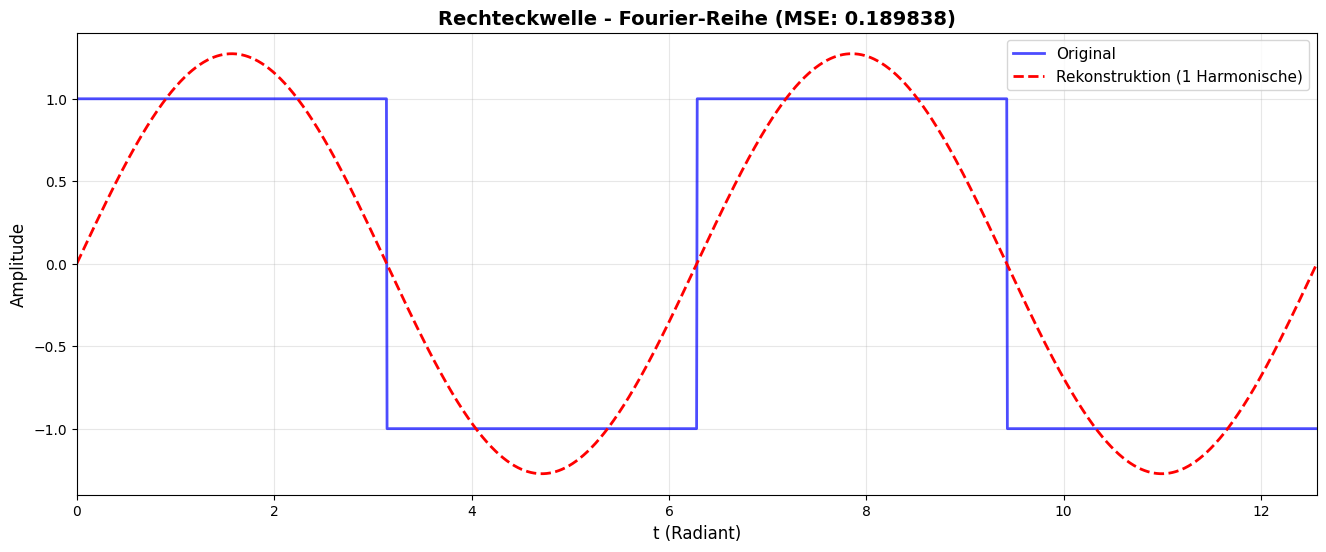


📊 Fourier-Reihen Zusammenfassung für Rechteckwelle:
   DC-Komponente (a₀): 0.0000
   Anzahl verwendeter Harmonischer: 1
   Mittlerer quadratischer Fehler: 0.189838

   Erste 5 Harmonische:
      n=1: aₙ= 0.0020, bₙ= 1.2732, |cₙ|=1.2732

Mit 3 Harmonischen:


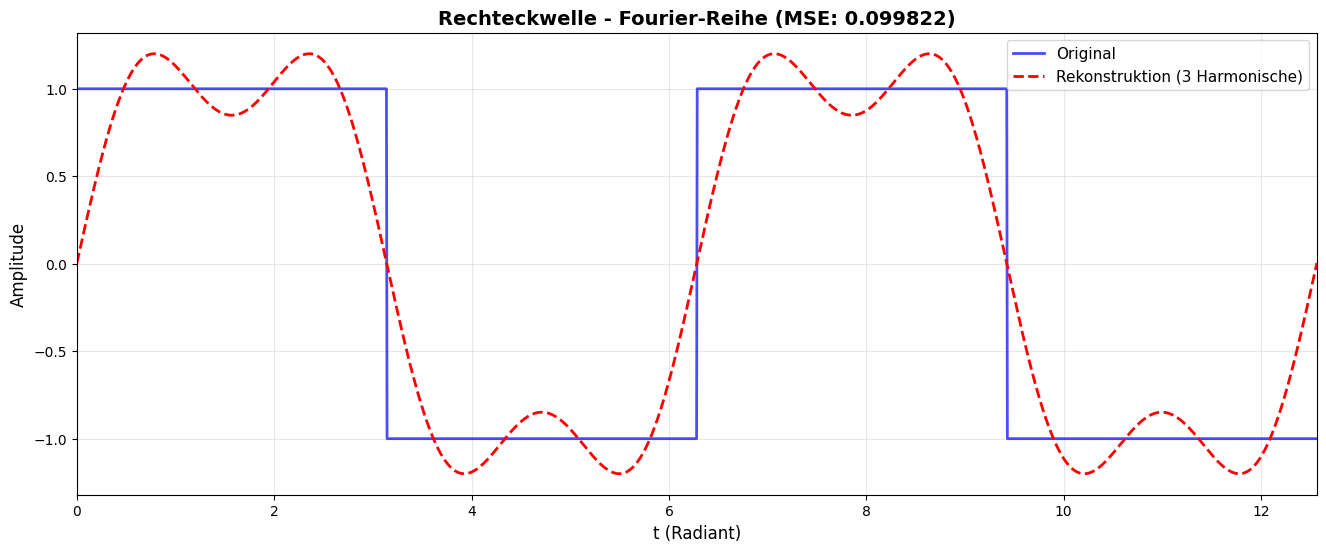


📊 Fourier-Reihen Zusammenfassung für Rechteckwelle:
   DC-Komponente (a₀): 0.0000
   Anzahl verwendeter Harmonischer: 3
   Mittlerer quadratischer Fehler: 0.099822

   Erste 5 Harmonische:
      n=1: aₙ= 0.0020, bₙ= 1.2732, |cₙ|=1.2732
      n=2: aₙ=-0.0000, bₙ=-0.0000, |cₙ|=0.0000
      n=3: aₙ= 0.0020, bₙ= 0.4244, |cₙ|=0.4244

Mit 7 Harmonischen:


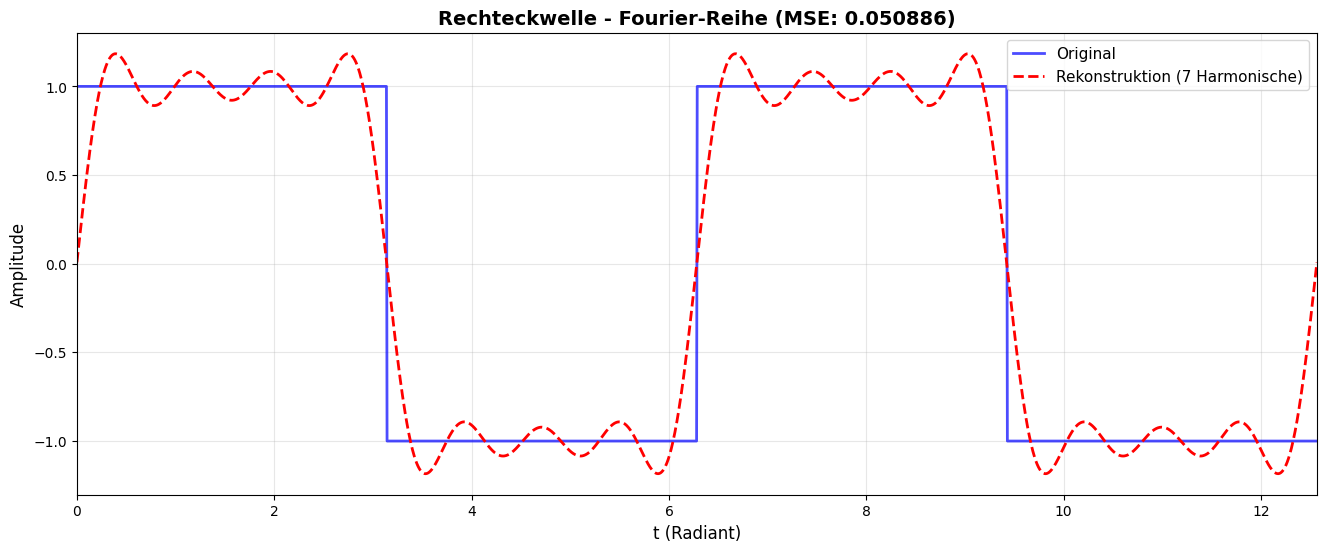


📊 Fourier-Reihen Zusammenfassung für Rechteckwelle:
   DC-Komponente (a₀): 0.0000
   Anzahl verwendeter Harmonischer: 7
   Mittlerer quadratischer Fehler: 0.050886

   Erste 5 Harmonische:
      n=1: aₙ= 0.0020, bₙ= 1.2732, |cₙ|=1.2732
      n=2: aₙ=-0.0000, bₙ=-0.0000, |cₙ|=0.0000
      n=3: aₙ= 0.0020, bₙ= 0.4244, |cₙ|=0.4244
      n=4: aₙ=-0.0000, bₙ=-0.0000, |cₙ|=0.0000
      n=5: aₙ= 0.0020, bₙ= 0.2546, |cₙ|=0.2546

Mit 15 Harmonischen:


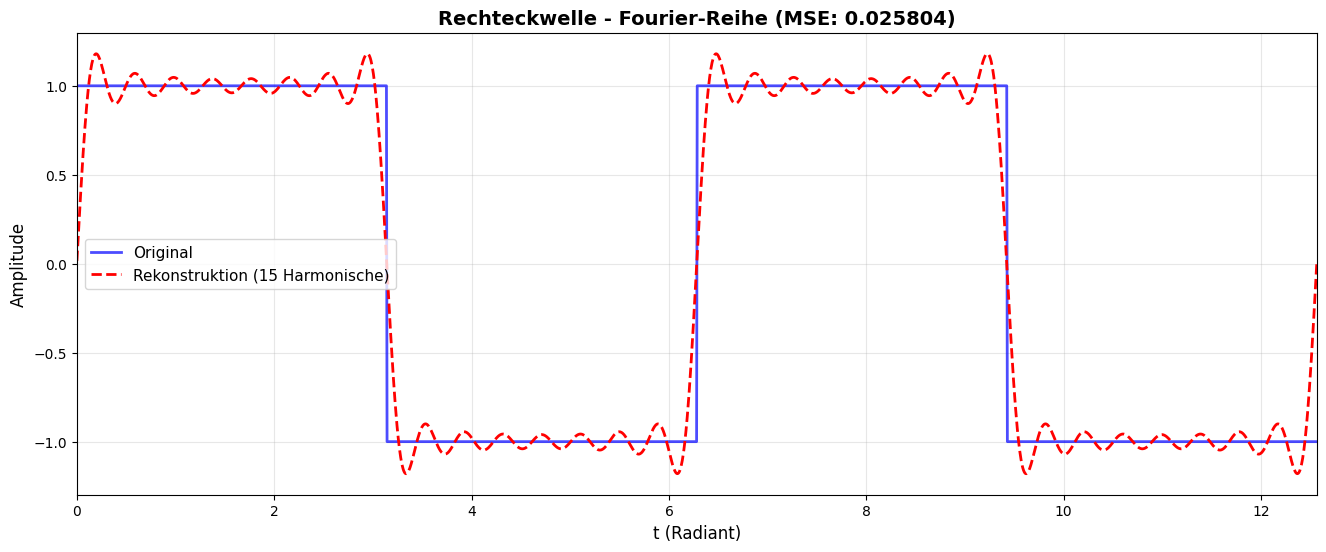


📊 Fourier-Reihen Zusammenfassung für Rechteckwelle:
   DC-Komponente (a₀): 0.0000
   Anzahl verwendeter Harmonischer: 15
   Mittlerer quadratischer Fehler: 0.025804

   Erste 5 Harmonische:
      n=1: aₙ= 0.0020, bₙ= 1.2732, |cₙ|=1.2732
      n=2: aₙ=-0.0000, bₙ=-0.0000, |cₙ|=0.0000
      n=3: aₙ= 0.0020, bₙ= 0.4244, |cₙ|=0.4244
      n=4: aₙ=-0.0000, bₙ=-0.0000, |cₙ|=0.0000
      n=5: aₙ= 0.0020, bₙ= 0.2546, |cₙ|=0.2546

Mit 50 Harmonischen:


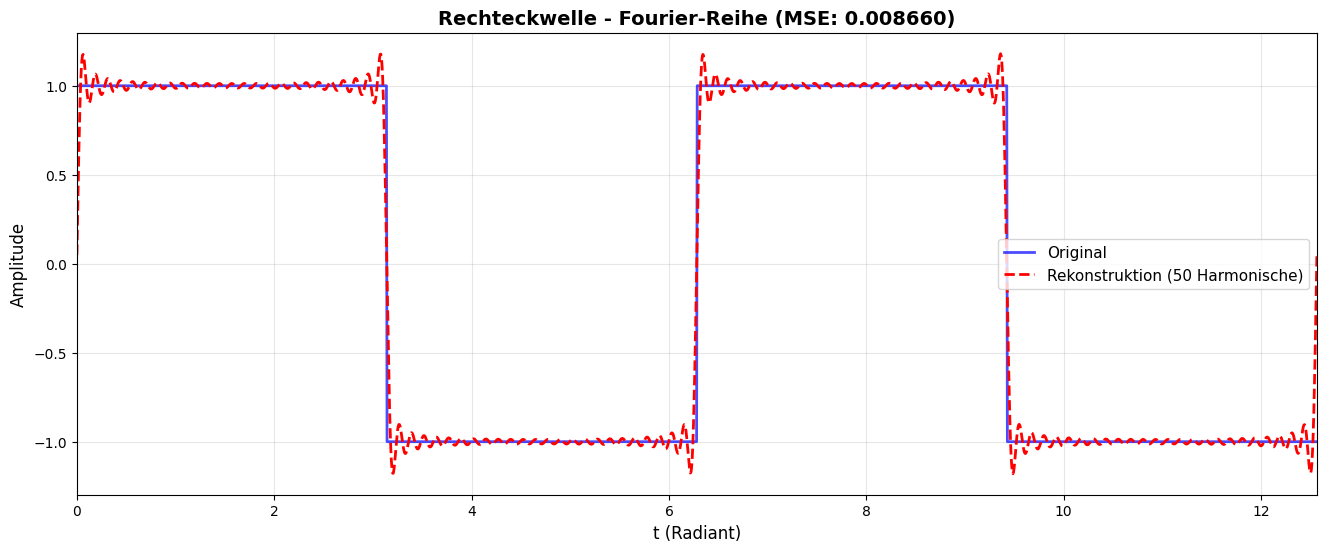


📊 Fourier-Reihen Zusammenfassung für Rechteckwelle:
   DC-Komponente (a₀): 0.0000
   Anzahl verwendeter Harmonischer: 50
   Mittlerer quadratischer Fehler: 0.008660

   Erste 5 Harmonische:
      n=1: aₙ= 0.0020, bₙ= 1.2732, |cₙ|=1.2732
      n=2: aₙ=-0.0000, bₙ=-0.0000, |cₙ|=0.0000
      n=3: aₙ= 0.0020, bₙ= 0.4244, |cₙ|=0.4244
      n=4: aₙ=-0.0000, bₙ=-0.0000, |cₙ|=0.0000
      n=5: aₙ= 0.0020, bₙ= 0.2546, |cₙ|=0.2546


In [4]:
print('Rechteckwellen-Analyse:\n')

# Verschiedene Anzahlen von Harmonischen vergleichen
for n in [1, 3, 7, 15, 50]:
    print(f'\n{"="*60}')
    print(f'Mit {n} Harmonischen:')
    demo.plot_zerlegung('Rechteckwelle', n, zeige_harmonische=False)

### Beispiel 2: Dreieckwelle - Schnellere Konvergenz

**Theorie:** Dreieckwelle hat auch **nur ungerade Harmonische**, aber Amplituden nehmen mit 1/n² ab.

$$f(t) = \frac{8}{\pi^2} \sum_{n=1,3,5,...}^{\infty} \frac{(-1)^{(n-1)/2}}{n^2} \sin(nt)$$

**Wichtige Beobachtungen:**
- Konvergiert viel schneller als Rechteckwelle (1/n² vs 1/n)
- Glattere Form erfordert weniger hohe Frequenzen
- Kein Gibbs-Phänomen (stetige Ableitung)

Dreieckwellen-Analyse:


Mit 1 Harmonischen:


/tmp/ipykernel_174/3160423585.py:66: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  an[n-1] = (2/T) * np.trapz(
/tmp/ipykernel_174/3160423585.py:72: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  bn[n-1] = (2/T) * np.trapz(


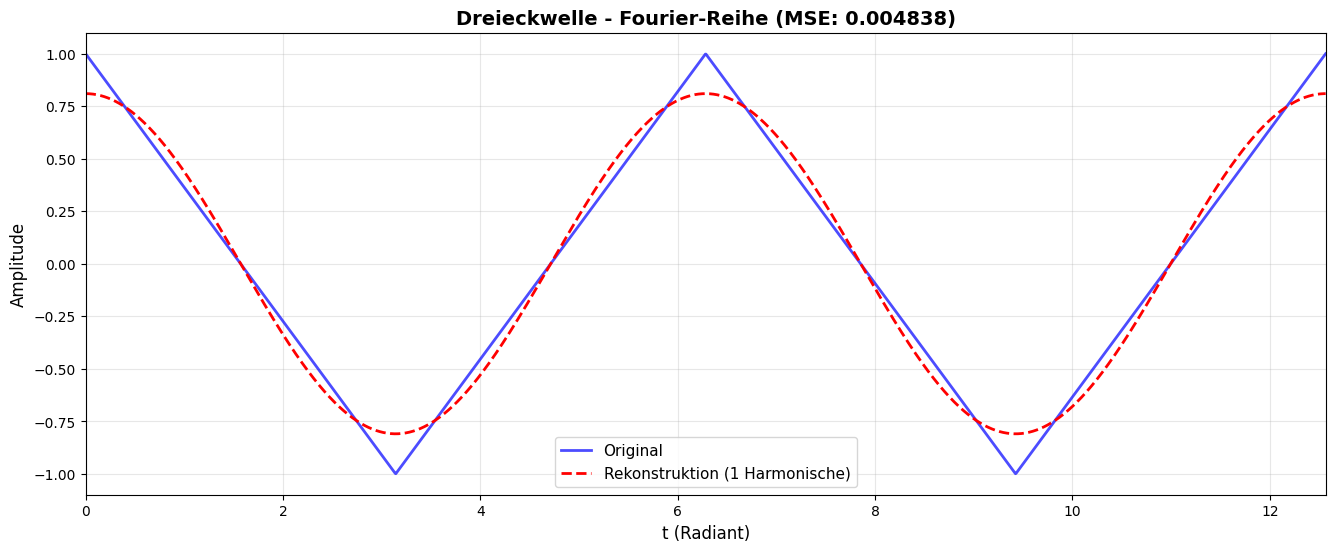


📊 Fourier-Reihen Zusammenfassung für Dreieckwelle:
   DC-Komponente (a₀): 0.0005
   Anzahl verwendeter Harmonischer: 1
   Mittlerer quadratischer Fehler: 0.004838

   Erste 5 Harmonische:
      n=1: aₙ= 0.8096, bₙ= 0.0000, |cₙ|=0.8096

Mit 3 Harmonischen:


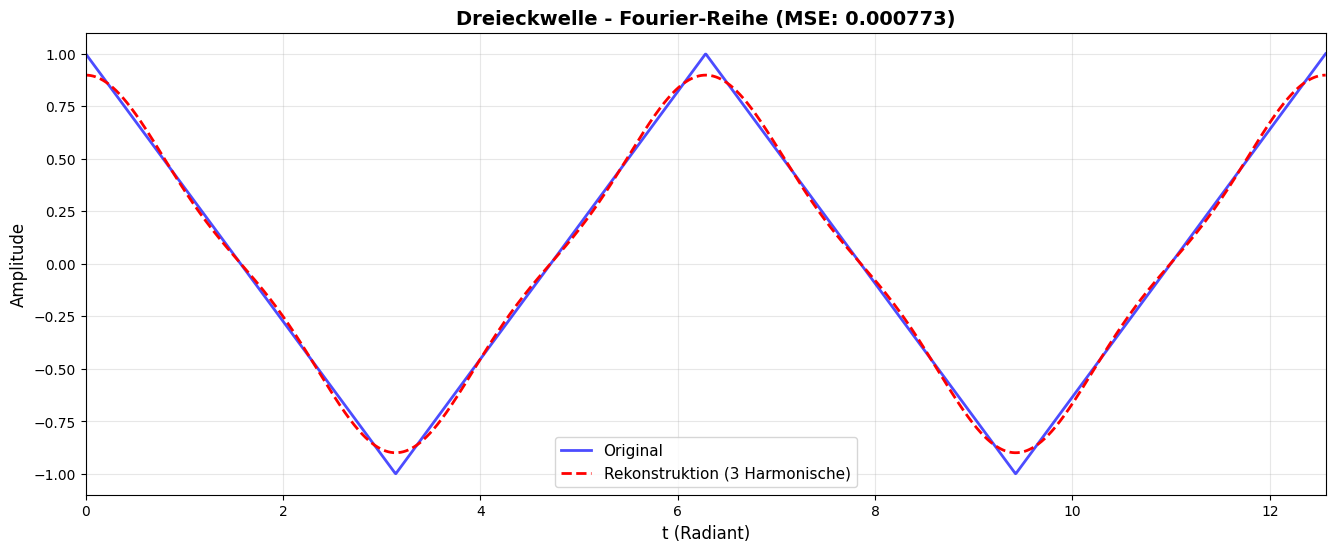


📊 Fourier-Reihen Zusammenfassung für Dreieckwelle:
   DC-Komponente (a₀): 0.0005
   Anzahl verwendeter Harmonischer: 3
   Mittlerer quadratischer Fehler: 0.000773

   Erste 5 Harmonische:
      n=1: aₙ= 0.8096, bₙ= 0.0000, |cₙ|=0.8096
      n=2: aₙ=-0.0010, bₙ= 0.0000, |cₙ|=0.0010
      n=3: aₙ= 0.0891, bₙ= 0.0000, |cₙ|=0.0891

Mit 7 Harmonischen:


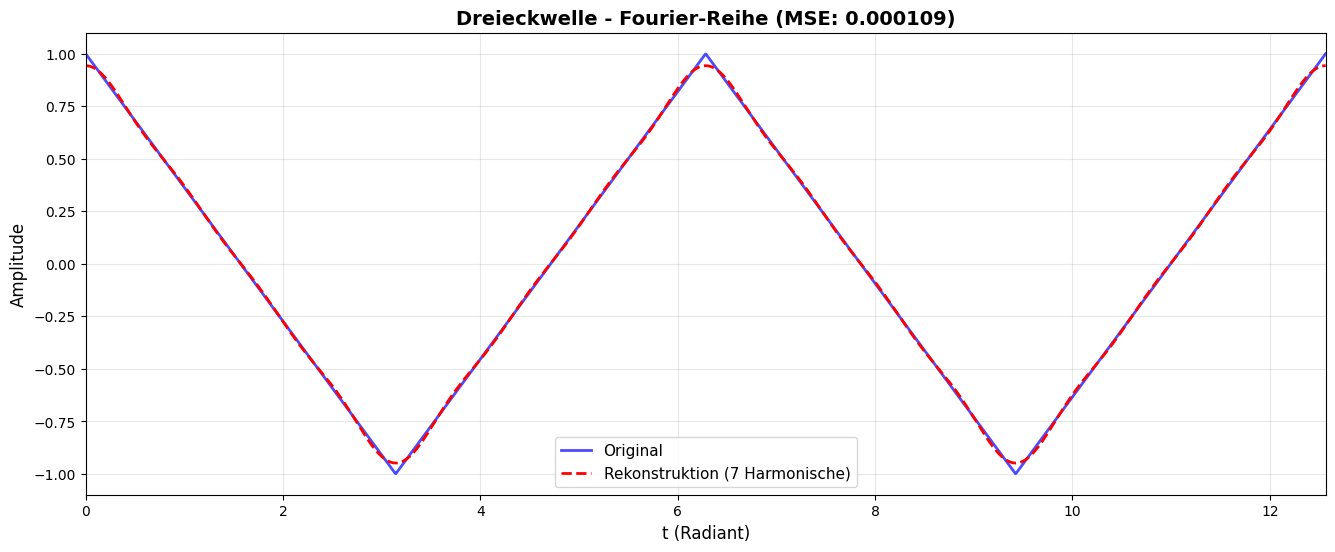


📊 Fourier-Reihen Zusammenfassung für Dreieckwelle:
   DC-Komponente (a₀): 0.0005
   Anzahl verwendeter Harmonischer: 7
   Mittlerer quadratischer Fehler: 0.000109

   Erste 5 Harmonische:
      n=1: aₙ= 0.8096, bₙ= 0.0000, |cₙ|=0.8096
      n=2: aₙ=-0.0010, bₙ= 0.0000, |cₙ|=0.0010
      n=3: aₙ= 0.0891, bₙ= 0.0000, |cₙ|=0.0891
      n=4: aₙ=-0.0010, bₙ= 0.0000, |cₙ|=0.0010
      n=5: aₙ= 0.0314, bₙ= 0.0000, |cₙ|=0.0314

Mit 15 Harmonischen:


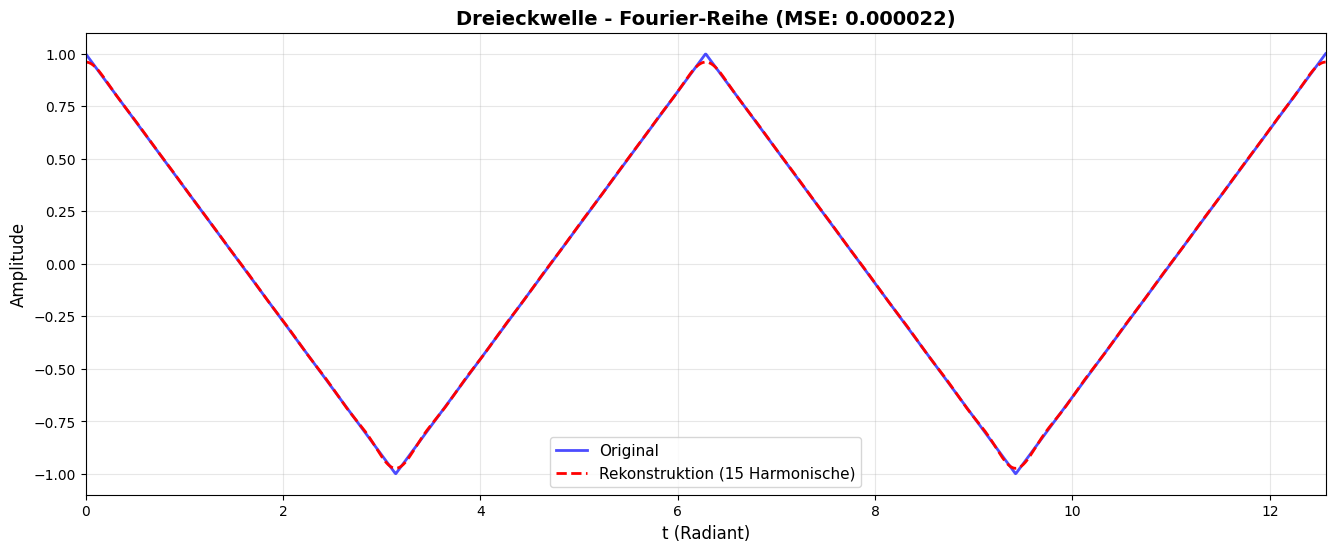


📊 Fourier-Reihen Zusammenfassung für Dreieckwelle:
   DC-Komponente (a₀): 0.0005
   Anzahl verwendeter Harmonischer: 15
   Mittlerer quadratischer Fehler: 0.000022

   Erste 5 Harmonische:
      n=1: aₙ= 0.8096, bₙ= 0.0000, |cₙ|=0.8096
      n=2: aₙ=-0.0010, bₙ= 0.0000, |cₙ|=0.0010
      n=3: aₙ= 0.0891, bₙ= 0.0000, |cₙ|=0.0891
      n=4: aₙ=-0.0010, bₙ= 0.0000, |cₙ|=0.0010
      n=5: aₙ= 0.0314, bₙ= 0.0000, |cₙ|=0.0314


In [5]:
print('Dreieckwellen-Analyse:\n')

for n in [1, 3, 7, 15]:
    print(f'\n{"="*60}')
    print(f'Mit {n} Harmonischen:')
    demo.plot_zerlegung('Dreieckwelle', n, zeige_harmonische=False)

---

## 📊 Konvergenzanalyse

Vergleichen wir quantitativ, wie schnell verschiedene Wellenformen konvergieren.

/tmp/ipykernel_174/3160423585.py:66: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  an[n-1] = (2/T) * np.trapz(
/tmp/ipykernel_174/3160423585.py:72: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  bn[n-1] = (2/T) * np.trapz(


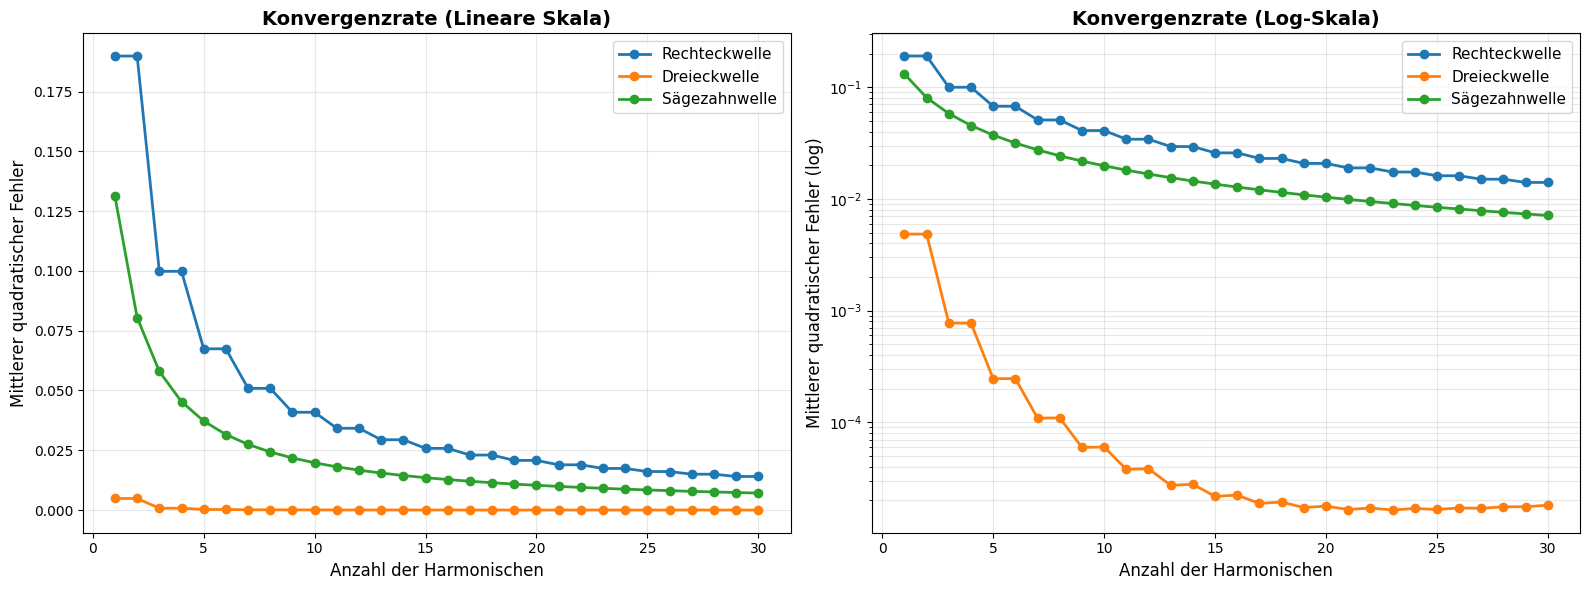


📈 Konvergenzanalyse:
   • Dreieckwelle: Schnellste Konvergenz (1/n² Abfall)
   • Sägezahnwelle: Mittlere Konvergenz (1/n Abfall)
   • Rechteckwelle: Langsamste Konvergenz (1/n Abfall + Unstetigkeiten)

   💡 Glattere Signale = weniger Harmonische benötigt!


In [6]:
def analysiere_konvergenz(wellenformen, max_harmonics=30):
    """
    Analysieren wie Fehler mit Anzahl der Harmonischen abnimmt
    """
    demo = FourierReihenDemo(num_periods=2, num_points=2000)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    for wellenform in wellenformen:
        # Wellenform erzeugen
        wellenform_funcs = {
            'Rechteckwelle': demo.rechteckwelle,
            'Dreieckwelle': demo.dreieckwelle,
            'Sägezahnwelle': demo.saegezahnwelle,
        }

        original = wellenform_funcs[wellenform](demo.t)

        # Koeffizienten einmal berechnen
        a0, an, bn = demo.berechne_fourier_koeffizienten(original, max_harmonics)

        # Fehler für verschiedene Anzahlen von Harmonischen berechnen
        errors = []
        n_harmonics_range = range(1, max_harmonics + 1)

        for n in n_harmonics_range:
            reconstructed, _ = demo.rekonstruiere_signal(a0, an, bn, n)
            mse = np.mean((original - reconstructed)**2)
            errors.append(mse)

        # Ergebnisse plotten
        ax1.plot(n_harmonics_range, errors, marker='o', label=wellenform, linewidth=2)
        ax2.semilogy(n_harmonics_range, errors, marker='o', label=wellenform, linewidth=2)

    # Plots formatieren
    ax1.set_xlabel('Anzahl der Harmonischen', fontsize=12)
    ax1.set_ylabel('Mittlerer quadratischer Fehler', fontsize=12)
    ax1.set_title('Konvergenzrate (Lineare Skala)', fontsize=14, fontweight='bold')
    ax1.legend(fontsize=11)
    ax1.grid(True, alpha=0.3)

    ax2.set_xlabel('Anzahl der Harmonischen', fontsize=12)
    ax2.set_ylabel('Mittlerer quadratischer Fehler (log)', fontsize=12)
    ax2.set_title('Konvergenzrate (Log-Skala)', fontsize=14, fontweight='bold')
    ax2.legend(fontsize=11)
    ax2.grid(True, alpha=0.3, which='both')

    plt.tight_layout()
    plt.show()

    print('\n📈 Konvergenzanalyse:')
    print('   • Dreieckwelle: Schnellste Konvergenz (1/n² Abfall)')
    print('   • Sägezahnwelle: Mittlere Konvergenz (1/n Abfall)')
    print('   • Rechteckwelle: Langsamste Konvergenz (1/n Abfall + Unstetigkeiten)')
    print('\n   💡 Glattere Signale = weniger Harmonische benötigt!')

# Konvergenzanalyse durchführen
analysiere_konvergenz(['Rechteckwelle', 'Dreieckwelle', 'Sägezahnwelle'], max_harmonics=30)

---

## 🎓 Wichtigste Erkenntnisse

### Was wir gelernt haben:

1. **Jedes periodische Signal = Summe von Sinuswellen**
   - Jede Sinuswelle ist eine "Harmonische" (ganzzahliges Vielfaches der Grundfrequenz)
   - Mehr Harmonische = bessere Approximation

2. **Verschiedene Signale benötigen unterschiedlich viele Harmonische**
   - Scharfe Kanten (Rechteckwelle) → viele Harmonische benötigt
   - Glatte Kurven (Dreieckwelle) → weniger Harmonische benötigt

3. **Symmetrie ist wichtig**
   - Ungerade Symmetrie → nur Sinus-Terme
   - Gerade Symmetrie → nur Kosinus-Terme
   - Keine Symmetrie → beide Sinus- und Kosinus-Terme

4. **Gibbs-Phänomen**
   - Überschwingen nahe Unstetigkeiten
   - ~9% Überschwingen, verschwindet nicht mit mehr Harmonischen
   - Inhärent bei Fourier-Reihen-Approximation unstetiger Funktionen

### Praktische Anwendungen:

- **Audio-Synthese**: Musikalische Töne aus Harmonischen erzeugen
- **Signalverarbeitung**: Filterung, Kompression
- **Bildverarbeitung**: JPEG-Kompression nutzt ähnliche Konzepte (DCT)
- **Kommunikation**: Analyse periodischer Signale
- **Regelungstechnik**: Systemantwort auf verschiedene Frequenzen verstehen

---

## 🔬 Weitere Erkundung

**Probieren Sie diese Experimente:**

1. **Gibbs-Phänomen**: Rechteckwelle auf 50 Harmonische setzen, an Kante heranzoomen - sehen Sie das Überschwingen!

2. **Ungerade vs Gerade**: Rechteckwelle (nur ungerade Harmonische) vs Sägezahnwelle (alle Harmonischen) vergleichen

3. **Konvergenzgeschwindigkeit**: Fehlerabnahme für Dreieck- vs Rechteckwelle vergleichen

4. **DC-Komponente**: Halbwellen-Gleichgerichtet ausprobieren - DC-Komponente ungleich null beachten

**Fragen zum Nachdenken:**

- Warum erfordern scharfe Kanten mehr Harmonische?
- Was passiert wenn bestimmte Harmonische entfernt werden?
- Wie hängt dies mit Bildkompression zusammen?
- Wie würde ein nicht-periodisches Signal aussehen?

---

**🎉 Sie haben die Grundlagen der Fourier-Reihen gemeistert!**

Nächste Themen: Fourier-Transformation (für nicht-periodische Signale), FFT, Anwendungen in Bild-/Audioverarbeitung!